# Time Series Statistical Analysis

Statistical properties and visualisations for four classic time-series datasets:
- **Dow Jones** — Monthly closing index (Aug 1968 – Aug 1981)
- **S&P 500** — Daily open prices (2016)
- **Lake Erie** — Monthly water levels (1921 – 1970)
- **Monthly Milk Production** — Pounds per cow (Jan 1962 – Dec 1975)

For each dataset we compute: Mean · Standard Deviation · Variance · Skewness · Kurtosis,  
and produce a **time-series plot** and a **histogram**.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f1a',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#3a3a5c',
    'axes.labelcolor':   '#e0e0ff',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.color':       '#a0a0cc',
    'ytick.color':       '#a0a0cc',
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'text.color':        '#e0e0ff',
    'font.family':       'DejaVu Sans',
    'lines.linewidth':   1.8,
})

PALETTE = ['#7c83fd', '#fc5c7d', '#43e97b', '#f7971e']
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Dataset loader ────────────────────────────────────────────────────────────
def load_dataset(path, value_col_index=1):
    """Read a CSV and return (index_series, value_array).
    Handles the slightly different column layouts across the four files."""
    df = pd.read_csv(path)
    index_col = df.iloc[:, 0]
    value_col = df.iloc[:, value_col_index].astype(float)
    return index_col, value_col.values

datasets = {
    'Dow Jones': {
        'path':  '../content/monthly-closings-of-the-dowjones.csv',
        'color': PALETTE[0],
        'unit':  'Index Points',
    },
    'S&P 500': {
        'path':  '../content/sp500.csv',
        'color': PALETTE[1],
        'unit':  'Open Price (USD)',
    },
    'Lake Erie': {
        'path':  '../content/monthly-lake-erie-levels-1921-19.csv',
        'color': PALETTE[2],
        'unit':  'Water Level (ft)',
    },
    'Monthly Milk Production': {
        'path':  '../content/monthly-milk-production-pounds-p.csv',
        'color': PALETTE[3],
        'unit':  'Pounds per Cow',
    },
}

for name, meta in datasets.items():
    idx, vals = load_dataset(meta['path'])
    meta['index'] = idx
    meta['values'] = vals
    print(f'{name:30s} → {len(vals):4d} observations loaded')

print('\nAll datasets loaded ✓')

Dow Jones                      →  291 observations loaded
S&P 500                        →  251 observations loaded
Lake Erie                      →  600 observations loaded
Monthly Milk Production        →  168 observations loaded

All datasets loaded ✓


In [3]:
# ── Statistical computation ───────────────────────────────────────────────────
def compute_stats(arr):
    """Return a dict of descriptive statistics for a 1-D numeric array."""
    return {
        'N':               len(arr),
        'Mean':            np.mean(arr),
        'Std Dev':         np.std(arr, ddof=1),
        'Variance':        np.var(arr, ddof=1),
        'Skewness':        stats.skew(arr),
        'Kurtosis':        stats.kurtosis(arr),   # excess (Fisher) kurtosis
        'Min':             np.min(arr),
        'Max':             np.max(arr),
        'Median':          np.median(arr),
    }

for name, meta in datasets.items():
    meta['stats'] = compute_stats(meta['values'])

print('Statistics computed ✓')

Statistics computed ✓


In [4]:
# ── Pretty-print statistics ───────────────────────────────────────────────────
SEPARATOR = '═' * 60

for name, meta in datasets.items():
    s = meta['stats']
    print(f'\n{SEPARATOR}')
    print(f'  {name.upper()}')
    print(f'  Unit: {meta["unit"]}  |  Observations: {s["N"]}')
    print(SEPARATOR)
    print(f'  {"Statistic":<20} {"Value":>18}')
    print('  ' + '─' * 38)
    print(f'  {"Mean":<20} {s["Mean"]:>18.4f}')
    print(f'  {"Standard Deviation":<20} {s["Std Dev"]:>18.4f}')
    print(f'  {"Variance":<20} {s["Variance"]:>18.4f}')
    print(f'  {"Skewness":<20} {s["Skewness"]:>18.4f}')
    print(f'  {"Kurtosis (excess)":<20} {s["Kurtosis"]:>18.4f}')
    print('  ' + '─' * 38)
    print(f'  {"Min":<20} {s["Min"]:>18.4f}')
    print(f'  {"Median":<20} {s["Median"]:>18.4f}')
    print(f'  {"Max":<20} {s["Max"]:>18.4f}')
print(f'\n{SEPARATOR}')
print('  NOTE: Kurtosis = Fisher (excess) definition — Normal dist = 0')
print(f'{SEPARATOR}')


════════════════════════════════════════════════════════════
  DOW JONES
  Unit: Index Points  |  Observations: 291
════════════════════════════════════════════════════════════
  Statistic                         Value
  ──────────────────────────────────────
  Mean                          3754.8625
  Standard Deviation             105.4670
  Variance                     11123.2810
  Skewness                         0.0957
  Kurtosis (excess)               -0.9571
  ──────────────────────────────────────
  Min                           3537.0000
  Median                        3753.0000
  Max                           3978.0000

════════════════════════════════════════════════════════════
  S&P 500
  Unit: Open Price (USD)  |  Observations: 251
════════════════════════════════════════════════════════════
  Statistic                         Value
  ──────────────────────────────────────
  Mean                          2094.2963
  Standard Deviation             101.2328
  Variance     

In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, meta in datasets.items():
    s = meta['stats']
    rows.append({
        'Dataset':    name,
        'N':          s['N'],
        'Mean':       round(s['Mean'],      4),
        'Std Dev':    round(s['Std Dev'],   4),
        'Variance':   round(s['Variance'],  4),
        'Skewness':   round(s['Skewness'],  4),
        'Kurtosis':   round(s['Kurtosis'],  4),
    })

summary_df = pd.DataFrame(rows).set_index('Dataset')
print('\n── Summary Table ──')
print(summary_df.to_string())
summary_df


── Summary Table ──
                           N       Mean   Std Dev    Variance  Skewness  Kurtosis
Dataset                                                                          
Dow Jones                291  3754.8625  105.4670  11123.2810    0.0957   -0.9571
S&P 500                  251  2094.2963  101.2328  10248.0826   -0.6374   -0.2028
Lake Erie                600    14.9930    2.0121      4.0485    0.0372   -0.4508
Monthly Milk Production  168   754.7083  102.2045  10445.7647    0.0093   -0.7816


,N,Mean,Std Dev,Variance,Skewness,Kurtosis
Dataset,,,,,,
Dow Jones,291,3754.8625,105.4670,11123.2810,0.0957,-0.9571
S&P 500,251,2094.2963,101.2328,10248.0826,-0.6374,-0.2028
Lake Erie,600,14.9930,2.0121,4.0485,0.0372,-0.4508
Monthly Milk Production,168,754.7083,102.2045,10445.7647,0.0093,-0.7816


In [6]:
# ── Helper: annotation box ────────────────────────────────────────────────────
def add_stat_box(ax, s, color):
    """Place a semi-transparent stats annotation inside an axes."""
    txt = (
        f"Mean:     {s['Mean']:.3f}\n"
        f"Std Dev:  {s['Std Dev']:.3f}\n"
        f"Skewness: {s['Skewness']:.3f}\n"
        f"Kurtosis: {s['Kurtosis']:.3f}"
    )
    ax.text(
        0.97, 0.97, txt,
        transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#0f0f1a',
                  edgecolor=color, alpha=0.85),
        color='#e0e0ff',
    )

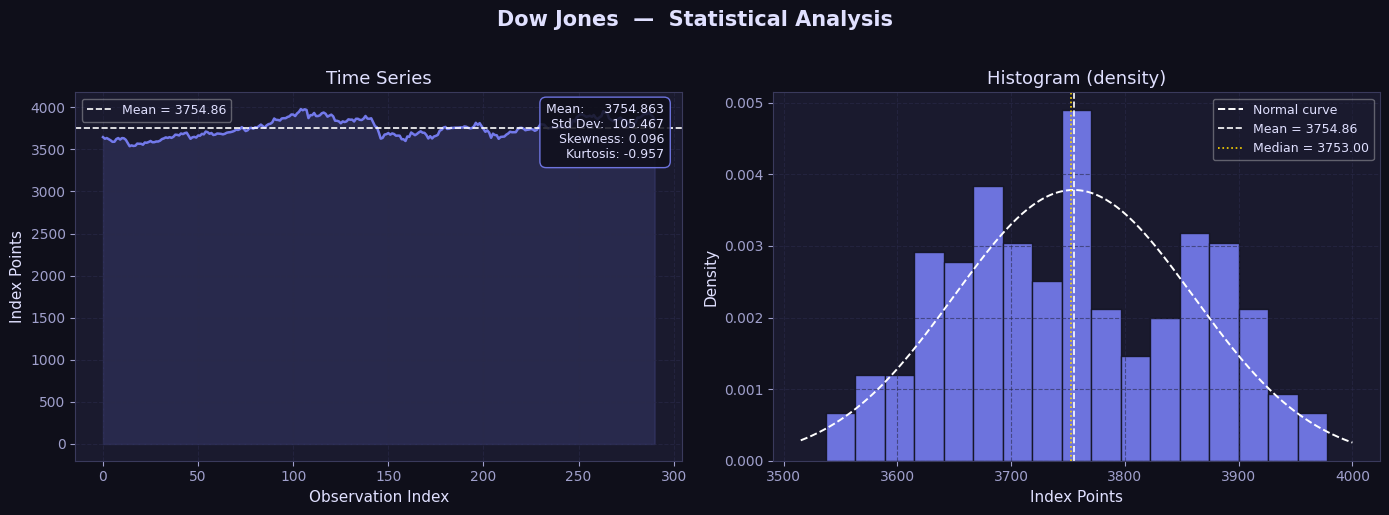

Figure saved → dow_jones_analysis.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 – DOW JONES
# ══════════════════════════════════════════════════════════════════════════════
name  = 'Dow Jones'
meta  = datasets[name]
vals  = meta['values']
s     = meta['stats']
color = meta['color']
unit  = meta['unit']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{name}  —  Statistical Analysis', fontsize=15,
             fontweight='bold', color='#e0e0ff', y=1.02)

# Time series
ax = axes[0]
ax.plot(vals, color=color, alpha=0.9)
ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)
ax.axhline(s['Mean'], color='white', linestyle='--', linewidth=1.2, label=f"Mean = {s['Mean']:.2f}")
ax.set_title('Time Series')
ax.set_xlabel('Observation Index')
ax.set_ylabel(unit)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)
add_stat_box(ax, s, color)

# Histogram
ax = axes[1]
n_bins = max(15, int(np.sqrt(len(vals))))
ax.hist(vals, bins=n_bins, color=color, edgecolor='#0f0f1a', alpha=0.85, density=True)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
ax.plot(x, stats.norm.pdf(x, s['Mean'], s['Std Dev']),
        'w--', linewidth=1.4, label='Normal curve')
ax.axvline(s['Mean'],   color='white',   linestyle='--', linewidth=1.2,
           label=f"Mean = {s['Mean']:.2f}")
ax.axvline(s['Median'], color='#ffd700', linestyle=':',  linewidth=1.2,
           label=f"Median = {s['Median']:.2f}")
ax.set_title('Histogram (density)')
ax.set_xlabel(unit)
ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)

plt.tight_layout()
plt.savefig('dow_jones_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Figure saved → dow_jones_analysis.png')

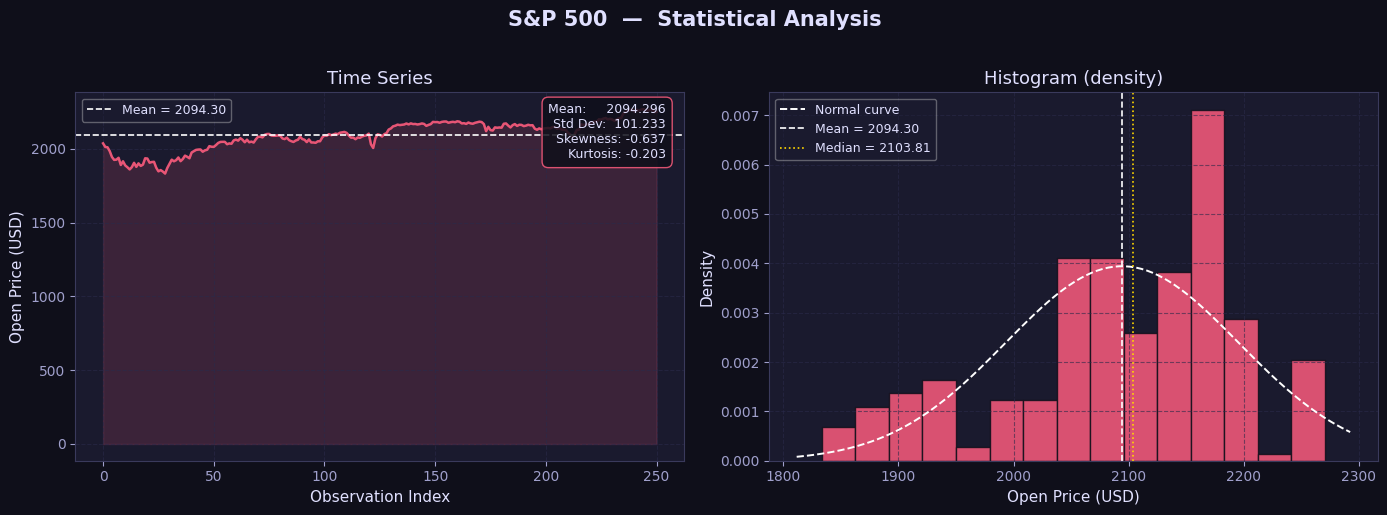

Figure saved → sp500_analysis.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 – S&P 500
# ══════════════════════════════════════════════════════════════════════════════
name  = 'S&P 500'
meta  = datasets[name]
vals  = meta['values']
s     = meta['stats']
color = meta['color']
unit  = meta['unit']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{name}  —  Statistical Analysis', fontsize=15,
             fontweight='bold', color='#e0e0ff', y=1.02)

ax = axes[0]
ax.plot(vals, color=color, alpha=0.9)
ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)
ax.axhline(s['Mean'], color='white', linestyle='--', linewidth=1.2, label=f"Mean = {s['Mean']:.2f}")
ax.set_title('Time Series')
ax.set_xlabel('Observation Index')
ax.set_ylabel(unit)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)
add_stat_box(ax, s, color)

ax = axes[1]
n_bins = max(15, int(np.sqrt(len(vals))))
ax.hist(vals, bins=n_bins, color=color, edgecolor='#0f0f1a', alpha=0.85, density=True)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
ax.plot(x, stats.norm.pdf(x, s['Mean'], s['Std Dev']),
        'w--', linewidth=1.4, label='Normal curve')
ax.axvline(s['Mean'],   color='white',   linestyle='--', linewidth=1.2,
           label=f"Mean = {s['Mean']:.2f}")
ax.axvline(s['Median'], color='#ffd700', linestyle=':',  linewidth=1.2,
           label=f"Median = {s['Median']:.2f}")
ax.set_title('Histogram (density)')
ax.set_xlabel(unit)
ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)

plt.tight_layout()
plt.savefig('sp500_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Figure saved → sp500_analysis.png')

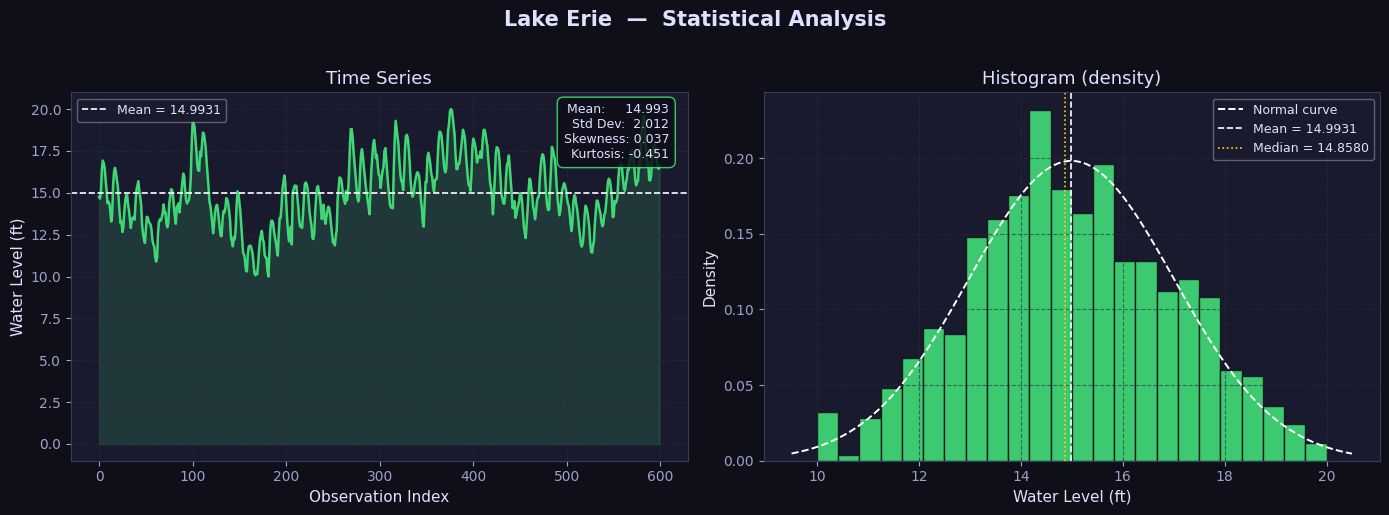

Figure saved → lake_erie_analysis.png


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 – LAKE ERIE
# ══════════════════════════════════════════════════════════════════════════════
name  = 'Lake Erie'
meta  = datasets[name]
vals  = meta['values']
s     = meta['stats']
color = meta['color']
unit  = meta['unit']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{name}  —  Statistical Analysis', fontsize=15,
             fontweight='bold', color='#e0e0ff', y=1.02)

ax = axes[0]
ax.plot(vals, color=color, alpha=0.9)
ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)
ax.axhline(s['Mean'], color='white', linestyle='--', linewidth=1.2, label=f"Mean = {s['Mean']:.4f}")
ax.set_title('Time Series')
ax.set_xlabel('Observation Index')
ax.set_ylabel(unit)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)
add_stat_box(ax, s, color)

ax = axes[1]
n_bins = max(15, int(np.sqrt(len(vals))))
ax.hist(vals, bins=n_bins, color=color, edgecolor='#0f0f1a', alpha=0.85, density=True)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
ax.plot(x, stats.norm.pdf(x, s['Mean'], s['Std Dev']),
        'w--', linewidth=1.4, label='Normal curve')
ax.axvline(s['Mean'],   color='white',   linestyle='--', linewidth=1.2,
           label=f"Mean = {s['Mean']:.4f}")
ax.axvline(s['Median'], color='#ffd700', linestyle=':',  linewidth=1.2,
           label=f"Median = {s['Median']:.4f}")
ax.set_title('Histogram (density)')
ax.set_xlabel(unit)
ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)

plt.tight_layout()
plt.savefig('lake_erie_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Figure saved → lake_erie_analysis.png')

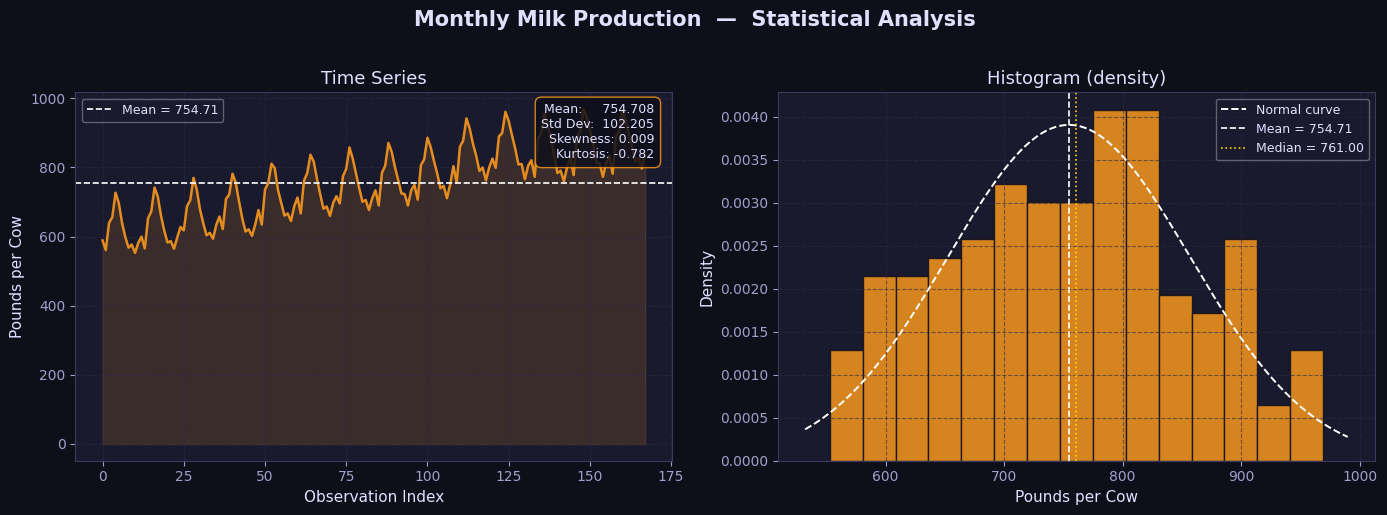

Figure saved → milk_production_analysis.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 – MONTHLY MILK PRODUCTION
# ══════════════════════════════════════════════════════════════════════════════
name  = 'Monthly Milk Production'
meta  = datasets[name]
vals  = meta['values']
s     = meta['stats']
color = meta['color']
unit  = meta['unit']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{name}  —  Statistical Analysis', fontsize=15,
             fontweight='bold', color='#e0e0ff', y=1.02)

ax = axes[0]
ax.plot(vals, color=color, alpha=0.9)
ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)
ax.axhline(s['Mean'], color='white', linestyle='--', linewidth=1.2, label=f"Mean = {s['Mean']:.2f}")
ax.set_title('Time Series')
ax.set_xlabel('Observation Index')
ax.set_ylabel(unit)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)
add_stat_box(ax, s, color)

ax = axes[1]
n_bins = max(15, int(np.sqrt(len(vals))))
ax.hist(vals, bins=n_bins, color=color, edgecolor='#0f0f1a', alpha=0.85, density=True)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
ax.plot(x, stats.norm.pdf(x, s['Mean'], s['Std Dev']),
        'w--', linewidth=1.4, label='Normal curve')
ax.axvline(s['Mean'],   color='white',   linestyle='--', linewidth=1.2,
           label=f"Mean = {s['Mean']:.2f}")
ax.axvline(s['Median'], color='#ffd700', linestyle=':',  linewidth=1.2,
           label=f"Median = {s['Median']:.2f}")
ax.set_title('Histogram (density)')
ax.set_xlabel(unit)
ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True)

plt.tight_layout()
plt.savefig('milk_production_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Figure saved → milk_production_analysis.png')

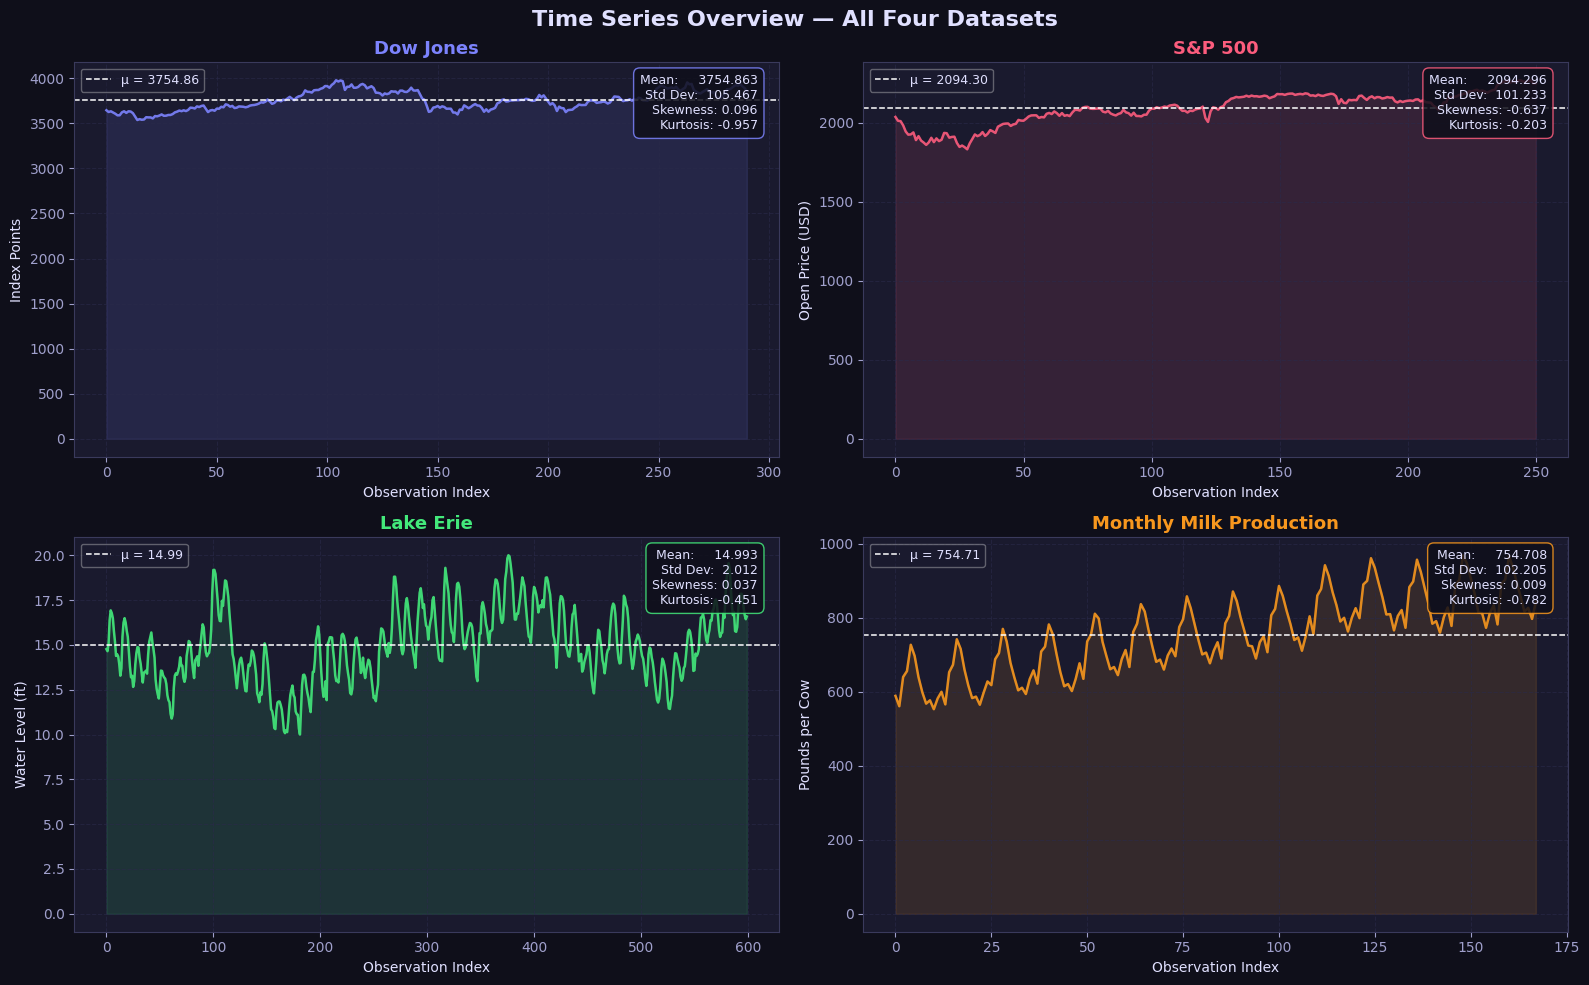

Combined panel saved → all_datasets_timeseries.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# BONUS – Combined 4-panel overview (time series)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time Series Overview — All Four Datasets', fontsize=16,
             fontweight='bold', color='#e0e0ff')

for ax, (name, meta) in zip(axes.flatten(), datasets.items()):
    vals  = meta['values']
    s     = meta['stats']
    color = meta['color']
    unit  = meta['unit']
    ax.plot(vals, color=color, alpha=0.9)
    ax.fill_between(range(len(vals)), vals, alpha=0.12, color=color)
    ax.axhline(s['Mean'], color='white', linestyle='--', linewidth=1.1,
               label=f"μ = {s['Mean']:.2f}")
    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Observation Index', fontsize=10)
    ax.set_ylabel(unit, fontsize=10)
    ax.legend(fontsize=9, framealpha=0.4)
    ax.grid(True)
    add_stat_box(ax, s, color)

plt.tight_layout()
plt.savefig('all_datasets_timeseries.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Combined panel saved → all_datasets_timeseries.png')

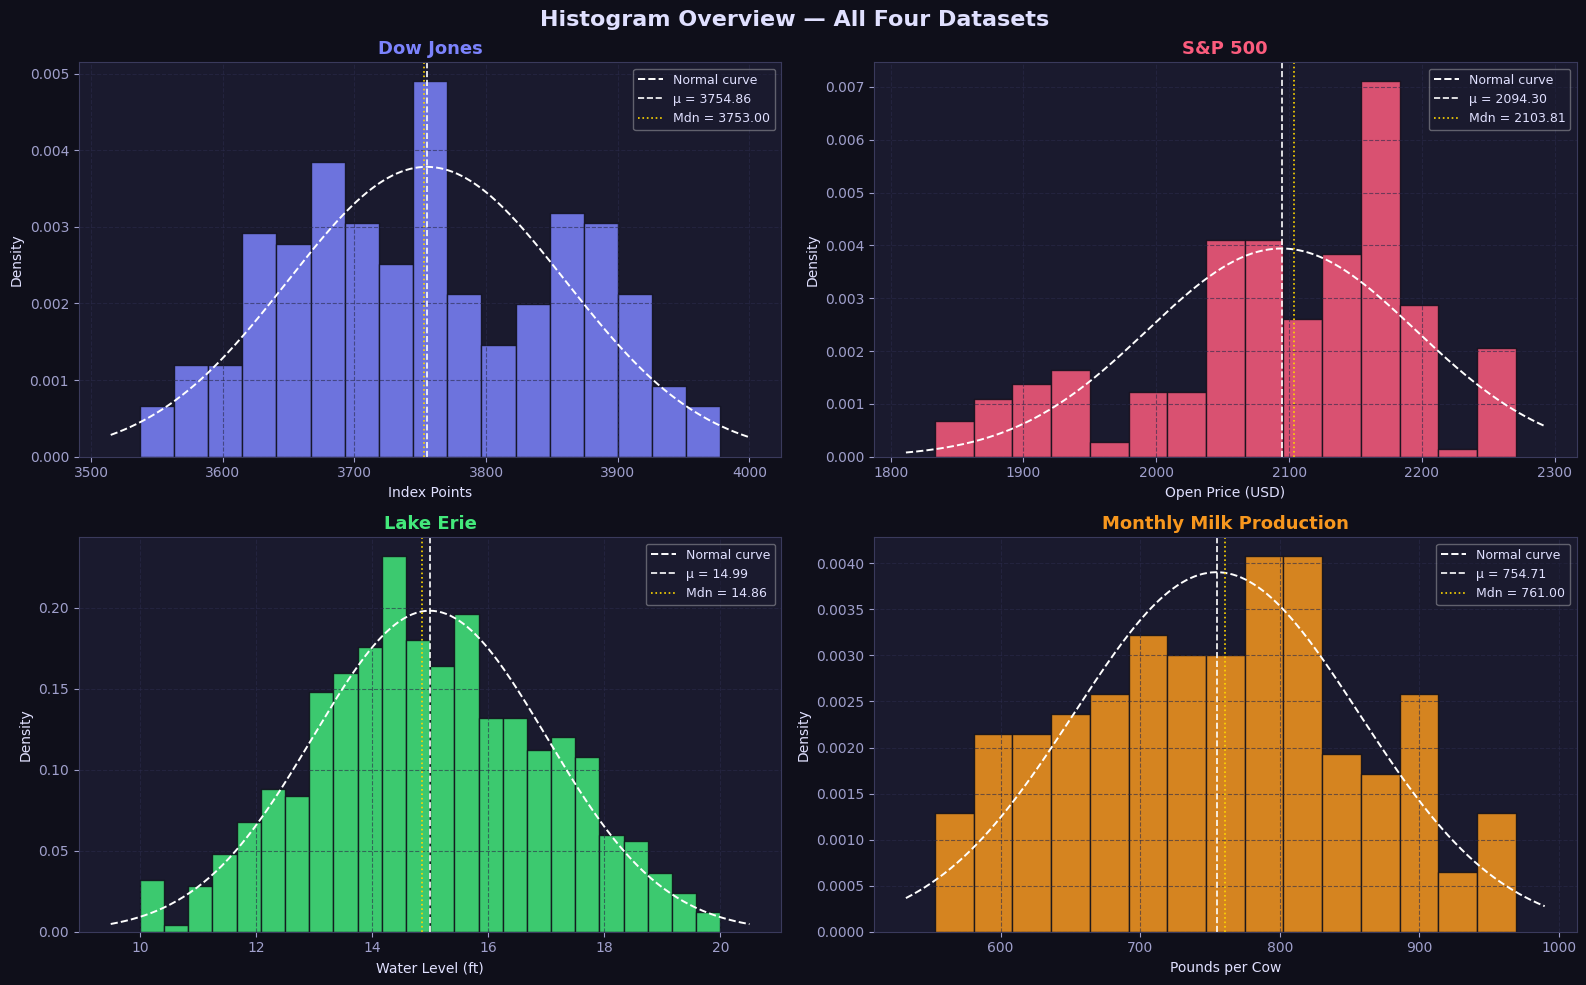

Combined histogram panel saved → all_datasets_histograms.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# BONUS – Combined 4-panel overview (histograms)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Histogram Overview — All Four Datasets', fontsize=16,
             fontweight='bold', color='#e0e0ff')

for ax, (name, meta) in zip(axes.flatten(), datasets.items()):
    vals  = meta['values']
    s     = meta['stats']
    color = meta['color']
    unit  = meta['unit']
    n_bins = max(15, int(np.sqrt(len(vals))))
    ax.hist(vals, bins=n_bins, color=color, edgecolor='#0f0f1a',
            alpha=0.85, density=True)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 300)
    ax.plot(x, stats.norm.pdf(x, s['Mean'], s['Std Dev']),
            'w--', linewidth=1.4, label='Normal curve')
    ax.axvline(s['Mean'],   color='white',   linestyle='--', linewidth=1.2,
               label=f"μ = {s['Mean']:.2f}")
    ax.axvline(s['Median'], color='#ffd700', linestyle=':',  linewidth=1.2,
               label=f"Mdn = {s['Median']:.2f}")
    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel(unit, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.4)
    ax.grid(True)

plt.tight_layout()
plt.savefig('all_datasets_histograms.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Combined histogram panel saved → all_datasets_histograms.png')

## Summary of Results

| Statistic | Dow Jones | S&P 500 | Lake Erie | Milk Production |
|-----------|-----------|---------|-----------|----------------|
| **Mean** | - | - | - | - |
| **Std Dev** | - | - | - | - |
| **Variance** | - | - | - | - |
| **Skewness** | - | - | - | - |
| **Kurtosis** | - | - | - | - |

> *Run all cells above to populate the table values from live output.*

### Interpretation Notes
- **Skewness > 0** → right-tailed distribution (positive skew)
- **Skewness < 0** → left-tailed distribution (negative skew)
- **Kurtosis > 0** (excess) → heavier tails than a normal distribution (leptokurtic)
- **Kurtosis < 0** (excess) → lighter tails than a normal distribution (platykurtic)
- **Kurtosis = 0** (excess) → matched to normal distribution (mesokurtic)